# Final Project: Single-Camera Bird's Eye View Scene Reconstruction with Object Detection

Computer Vision (CSE 559a)
Name: Irene Williams

Bird's Eye View (BEV) systems are increasingly used in modern vehicles to provide drivers with greater situational awareness for tasks such as parking, turning, and switching lanes. The goals of this project are to 1) successfully generate a panoramic image, 2) detect objects and 3) construct a synthetic top-down map centered on the camera with detected objects positioned relative to the camera.

In [1]:
import os
import glob
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature as skfeature
from PIL import Image
from ultralytics import YOLO

%matplotlib inline

## Setup

This notebook uses OpenCV for image processing and stitching, Ultralytics YOLOv8 for object detection, and matplotlib for visualization.  

The helper functions below load scene images, display intermediate outputs, and save results for later analysis.

In [32]:
def load_images(folder):
    # Load all images from a folder
    paths = sorted(glob.glob(os.path.join(folder, "*")))
    images = []

    for path in paths:
        img = cv2.imread(path)

        # fallback if OpenCV fails
        if img is None:
            try:
                img = np.array(Image.open(path).convert("RGB"))
                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            except:
                print("Failed to load:", path)
                continue

        images.append((path, img))

    return images

def display_image(img, title="", figsize=(10, 6)):
    if img is None:
        print("Image does not exist.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

def save_image(path, img):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    cv2.imwrite(path, img)

## Load Scene Images

In this section, we load the input images for one scene. These images should come from the same location, have substantial overlap, and be captured while rotating the camera gradually around the scene. This overlap is necessary for panorama stitching, since the algorithm relies on shared visual features between adjacent images.

In [3]:
scene_folder = "data/scene1"

images = load_images(scene_folder)
print(f"Loaded {len(images)} images from '{scene_folder}'")
for path, img in images:
    print(f"  {os.path.basename(path)}  {img.shape[1]}x{img.shape[0]}")

Loaded 11 images from 'data/scene1'
  IMG_7334.jpeg  4032x3024
  IMG_7335.jpeg  4032x3024
  IMG_7336.jpeg  4032x3024
  IMG_7337.jpeg  4032x3024
  IMG_7338.jpeg  4032x3024
  IMG_7339.jpeg  4032x3024
  IMG_7340.jpeg  4032x3024
  IMG_7341.jpeg  4032x3024
  IMG_7342.jpeg  4032x3024
  IMG_7343.jpeg  4032x3024
  IMG_7344.jpg  4032x3024


## Visualize Input Images

Before applying any preprocessing, we will visualize the raw images for a scene. This helps verify that the images were loaded correctly, that the images are in the expected order, that the scene has enough overlap for panorama stitching, and that lighting conditions are reasonably consistent.

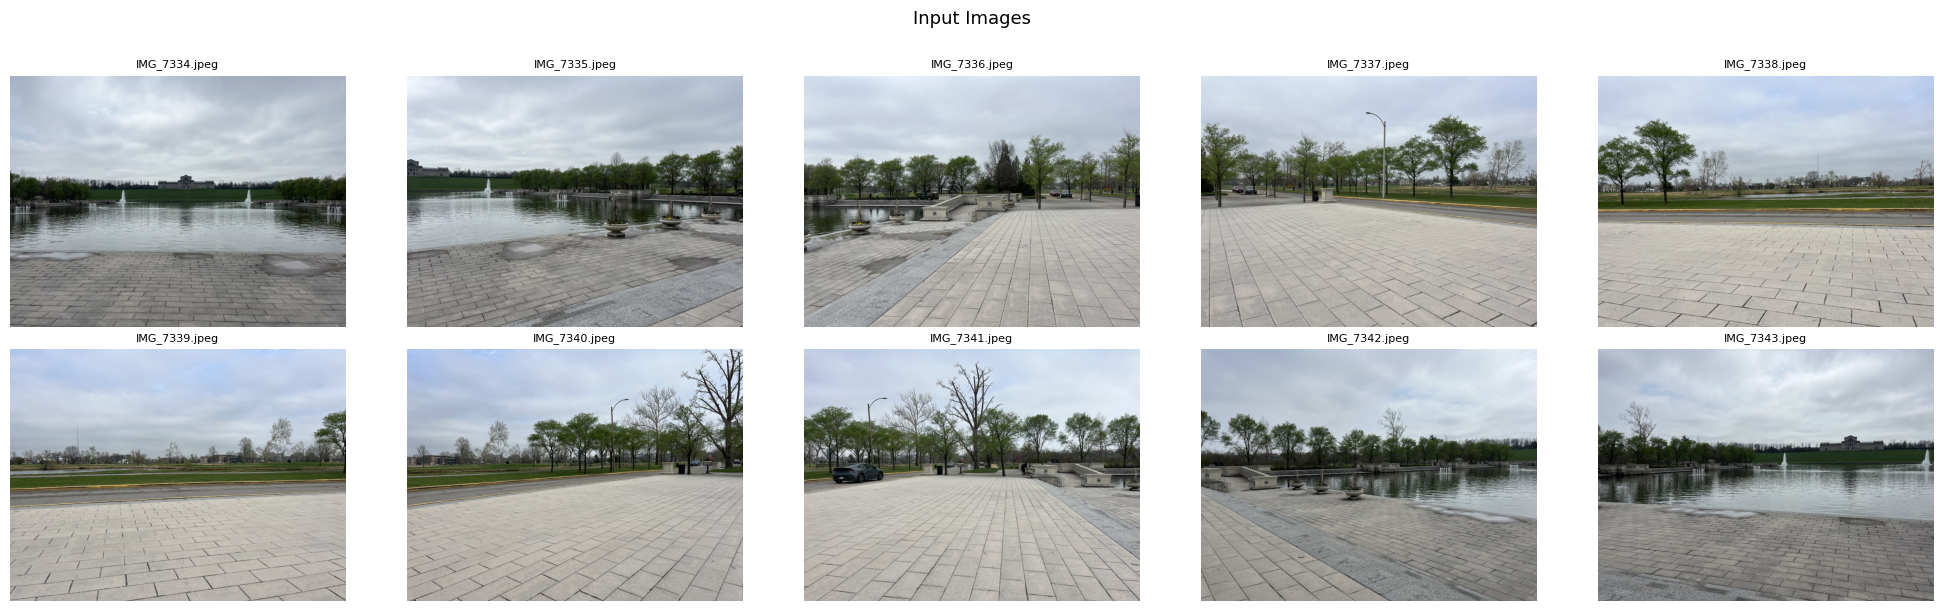

In [4]:
if len(images) == 0:
    print("No images found: check the scene_folder path.")
else:
    num_cols = 5
    num_show = min(len(images), 10)
    num_rows = math.ceil(num_show / num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    axes = np.array(axes).flatten()
    for i in range(len(axes)):
        if i < num_show:
            path, img = images[i]
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[i].set_title(os.path.basename(path), fontsize=8)
        axes[i].axis("off")
    plt.suptitle("Input Images", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## Panorama Stitching

The first major goal in this project is to combine all images into a single panorama. Panorama stitiching involves detecting keypoints in each image, matching features across image pairs, and warping/blending images into a common frame. 

For attempt #1, we tried to build our own stitching pipeline using cylindrical warping, SIFT feature matching, and an estimate of shifts between images. However, this did not work very well. The alignment was inconsistent and small errors kept accumulating, which made the final panorama look distorted. Due to this, we decided against using this method.

In [33]:
MAX_DIM = 1200
RATIO_TEST = 0.75
MIN_MATCHES = 20
GAUSSIAN_BLEND_KERNEL = 31

In [6]:
def resize_for_panorama(img: np.ndarray, max_dim: int = MAX_DIM):
    h, w = img.shape[:2]
    scale = min(1.0, max_dim / max(h, w))
    if scale < 1.0:
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return img, scale

In [7]:
def cylindrical_warp(img: np.ndarray, f: float):
    h, w = img.shape[:2]
    cx = w / 2.0
    cy = h / 2.0

    ys, xs = np.indices((h, w), dtype=np.float32)

    theta = (xs - cx) / f
    h_ = (ys - cy) / f

    X = np.tan(theta)
    Y = h_ / np.cos(theta)

    map_x = f * X + cx
    map_y = f * Y + cy

    cyl_img = cv2.remap(
        img,
        map_x.astype(np.float32),
        map_y.astype(np.float32),
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    valid = (
        (map_x >= 0) & (map_x < w) &
        (map_y >= 0) & (map_y < h)
    ).astype(np.uint8) * 255

    return cyl_img, valid

In [8]:
def estimate_shift_sift(img1: np.ndarray, img2: np.ndarray,
                        ratio_test: float = RATIO_TEST,
                        min_matches: int = MIN_MATCHES):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create(nfeatures=4000)
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        return None, None, 0

    bf = cv2.BFMatcher(cv2.NORM_L2)
    knn = bf.knnMatch(des1, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio_test * n.distance:
            good.append(m)

    if len(good) < min_matches:
        return None, None, len(good)

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 2)

    M, inliers = cv2.estimateAffinePartial2D(
        pts2, pts1,
        method=cv2.RANSAC,
        ransacReprojThreshold=3.0,
        maxIters=2000,
        confidence=0.99
    )

    if M is None:
        return None, None, 0

    dx = float(M[0, 2])
    dy = float(M[1, 2])
    num_inliers = int(inliers.sum()) if inliers is not None else 0

    return dx, dy, num_inliers

In [9]:
def compute_offsets(cyl_images):
    n = len(cyl_images)
    center = n // 2
    offsets = [None] * n
    offsets[center] = np.array([0.0, 0.0], dtype=np.float32)

    # go right
    for i in range(center + 1, n):
        dx, dy, nin = estimate_shift_sift(cyl_images[i - 1], cyl_images[i])
        print(f"{i-1} -> {i}: dx={dx}, dy={dy}, inliers={nin}")
        if dx is None:
            offsets[i] = offsets[i - 1].copy()
        else:
            offsets[i] = offsets[i - 1] + np.array([dx, dy], dtype=np.float32)

    # go left
    for i in range(center - 1, -1, -1):
        dx, dy, nin = estimate_shift_sift(cyl_images[i + 1], cyl_images[i])
        print(f"{i+1} -> {i}: dx={dx}, dy={dy}, inliers={nin}")
        if dx is None:
            offsets[i] = offsets[i + 1].copy()
        else:
            offsets[i] = offsets[i + 1] + np.array([dx, dy], dtype=np.float32)

    return offsets, center

In [10]:
def feather_alpha(mask: np.ndarray, ksize: int = GAUSSIAN_BLEND_KERNEL):
    alpha = mask.astype(np.float32) / 255.0
    alpha = cv2.GaussianBlur(alpha, (ksize, ksize), 0)
    alpha = np.clip(alpha, 0.0, 1.0)
    return alpha

In [11]:
def build_cylindrical_panorama(images, max_dim: int = MAX_DIM, focal_scale: float = 0.85):
    if len(images) < 2:
        print("Need at least 2 images.")
        return None, None, None

    # resize
    resized = []
    for path, img in images:
        img_small, scale = resize_for_panorama(img, max_dim)
        resized.append((path, img_small))

    # estimate focal length from image width
    sample_h, sample_w = resized[0][1].shape[:2]
    f = focal_scale * sample_w

    # cylindrical warp
    cyl_images = []
    cyl_masks = []
    for path, img in resized:
        cyl, mask = cylindrical_warp(img, f)
        cyl_images.append(cyl)
        cyl_masks.append(mask)

    # offsets
    offsets, center = compute_offsets(cyl_images)

    # canvas bounds
    xs = []
    ys = []
    for img, off in zip(cyl_images, offsets):
        h, w = img.shape[:2]
        xs.extend([off[0], off[0] + w])
        ys.extend([off[1], off[1] + h])

    min_x = int(np.floor(min(xs)))
    min_y = int(np.floor(min(ys)))
    max_x = int(np.ceil(max(xs)))
    max_y = int(np.ceil(max(ys)))

    pano_w = max_x - min_x
    pano_h = max_y - min_y

    accum = np.zeros((pano_h, pano_w, 3), dtype=np.float32)
    weight = np.zeros((pano_h, pano_w), dtype=np.float32)

    # blend all images
    for (path, img), mask, off in zip(resized, cyl_masks, offsets):
        h, w = img.shape[:2]
        x0 = int(round(off[0] - min_x))
        y0 = int(round(off[1] - min_y))

        alpha = feather_alpha(mask)

        accum[y0:y0+h, x0:x0+w] += img.astype(np.float32) * alpha[..., None]
        weight[y0:y0+h, x0:x0+w] += alpha

    pano = np.zeros_like(accum, dtype=np.uint8)
    valid = weight > 1e-6
    pano[valid] = (accum[valid] / weight[valid, None]).astype(np.uint8)

    return pano, offsets, (min_x, min_y)

Building panorama...
5 -> 6: dx=618.3053319258064, dy=-22.324899840940894, inliers=297
6 -> 7: dx=470.85882483560886, dy=-14.175519741352316, inliers=477
7 -> 8: dx=795.1050455285574, dy=-11.798485457753447, inliers=256
8 -> 9: dx=517.116056031318, dy=-1.1987964135758105, inliers=245
9 -> 10: dx=243.50157681938816, dy=8.632493943678254, inliers=281
5 -> 4: dx=-517.169472141876, dy=14.921275395881036, inliers=209
4 -> 3: dx=-653.0849544810133, dy=52.18860100849561, inliers=547
3 -> 2: dx=-717.4896028742244, dy=13.181527835932513, inliers=283
2 -> 1: dx=-737.1691315450455, dy=78.18580601393604, inliers=261
1 -> 0: dx=-571.118332088898, dy=-34.600945751788686, inliers=131

Panorama complete: 7042x1109 px


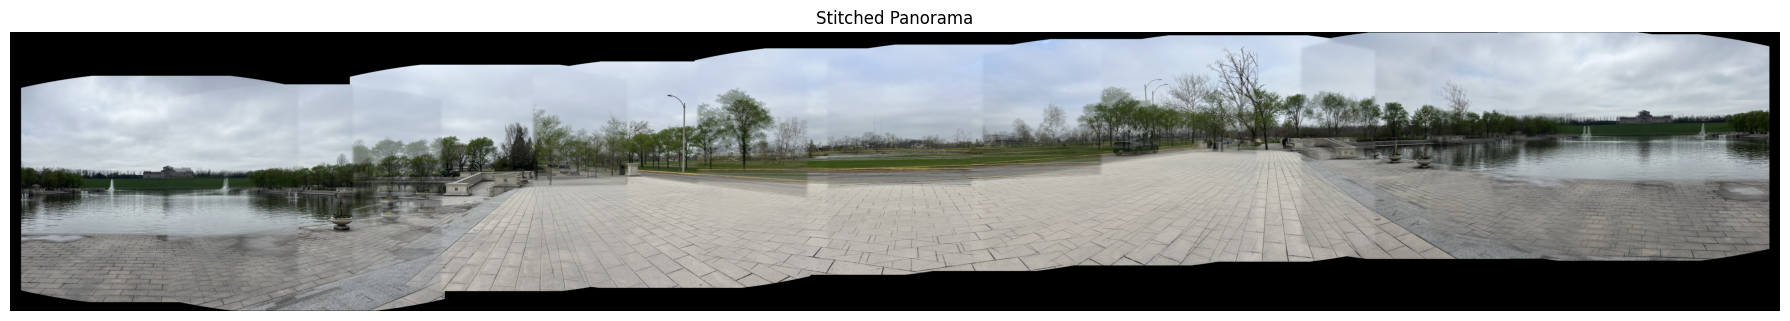

In [31]:
print("Building panorama...")
pano, offsets, origin = build_cylindrical_panorama(images, max_dim=1200, focal_scale=0.85)

if pano is None:
    print("Panorama construction failed")
else:
    print(f"\nPanorama complete: {pano.shape[1]}x{pano.shape[0]} px")
    display_image(pano, title="Stitched Panorama", figsize=(18, 6))
    save_image("outputs/pano.jpg", pano)

## Panorama Stitiching (Attempt #2)

We use OpenCV’s built in stitching pipeline. This produces a much cleaner panorama without needing to manually tune everything. We will use this method going forward.

In [35]:
pano = None

if len(images) < 2:
    print("Need at least 2 images for stitching.")
else:
    imgs = [img for _, img in images]
    
    stitcher = cv2.Stitcher_create()
    status, pano = stitcher.stitch(imgs)
    
    print("Status:", status) # 0 means success

Status: 0


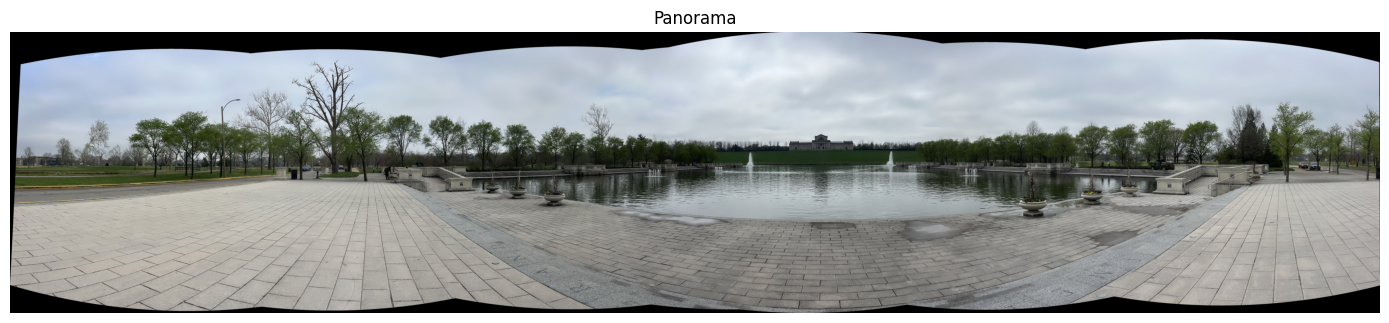

Panorama shape: (2963, 14438, 3)


In [14]:
if pano is None:
    print("No panorama to show.")
else:
    display_image(pano, title="Panorama", figsize=(14, 6))
    save_image("outputs/pano.jpg", pano)
    print("Panorama shape:", pano.shape)

## Object Detection (YOLO)

To incorporate semantic information to the scene, we apply YOLOv8, a pre-trained object detection model to the original images. The detector identifies objects such as people and cars, which will later be projected onto a synthetic top-down map. We first test object detection on a single image to verify that the model loads correctly, inference runs successfully and detected objects are reasonable for the given scene.

In [36]:
model = YOLO("yolov8n.pt")
print("YOLO loaded")

YOLO loaded


In [37]:
det_img = None

if model is None:
    print("YOLO not available")
elif len(images) == 0:
    print("No images available")
else:
    path, _ = images[7]
    results = model(path)
    det_img = results[0].plot()


image 1/1 /Users/irenewilliams/Desktop/Computer Vision/final project/data/scene1/IMG_7341.jpeg: 480x640 1 person, 3 cars, 1 bench, 83.3ms
Speed: 15.5ms preprocess, 83.3ms inference, 25.3ms postprocess per image at shape (1, 3, 480, 640)


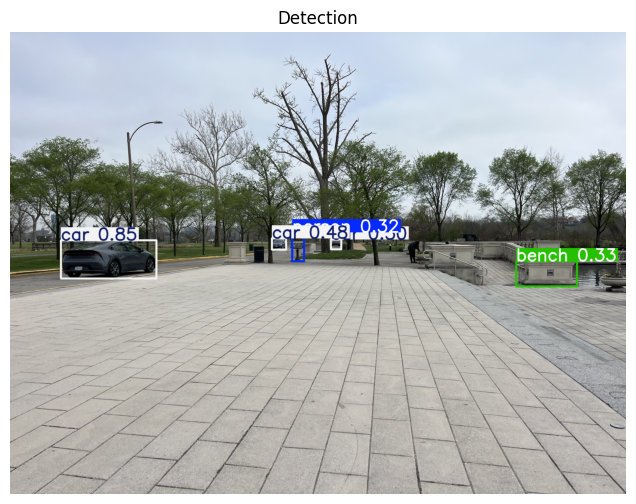

In [38]:
if det_img is None:
    print("No detection result")
else:
    display_image(det_img, title="Detection", figsize=(8, 6))
    save_image("outputs/detection_sample.jpg", det_img)

## Batch Detection Across the Full Scene

The next step is to run detection on all images in the scene. The detections will then be converted into approximate angular positions around the fixed viewpoint, which will form the basis of the synthetic top-down map.

In [40]:
def detect_objects(images, model):
    detections = []

    for i, (path, img) in enumerate(images):
        result = model(path)[0]

        annotated = result.plot()
        save_image(f"outputs/detections/{os.path.basename(path)}", annotated)

        if result.boxes is None:
            continue

        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

            detections.append({
                "image_idx": i,
                "bbox": [x1, y1, x2, y2],
                "class_id": int(box.cls[0]),
                "confidence": float(box.conf[0]),
                "img_shape": img.shape
            })

    return detections


all_detections = detect_objects(images, model) if len(images) > 0 else []
print(f"Collected {len(all_detections)} detections across the scene.")


image 1/1 /Users/irenewilliams/Desktop/Computer Vision/final project/data/scene1/IMG_7334.jpeg: 480x640 (no detections), 75.8ms
Speed: 6.1ms preprocess, 75.8ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /Users/irenewilliams/Desktop/Computer Vision/final project/data/scene1/IMG_7335.jpeg: 480x640 3 boats, 50.4ms
Speed: 4.7ms preprocess, 50.4ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /Users/irenewilliams/Desktop/Computer Vision/final project/data/scene1/IMG_7336.jpeg: 480x640 2 cars, 3 boats, 2 benchs, 59.1ms
Speed: 3.3ms preprocess, 59.1ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /Users/irenewilliams/Desktop/Computer Vision/final project/data/scene1/IMG_7337.jpeg: 480x640 2 cars, 54.8ms
Speed: 2.3ms preprocess, 54.8ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /Users/irenewilliams/Desktop/Computer Vision/final project/data/scene1/IMG_7338.jpeg: 480x64

## Estimating Relative Object Positions

A true automotive BEV system uses calibrated multi-camera geometry. In this project, a simpler approximation is used. Since the images were captured while rotating in place, each image corresponds to a different viewing direction. The horizontal position of each object in the image gives a rough angle, and the size of the bounding boxes gives a rough distance.

This does not compute true metric depth, but it is sufficient to build a basic top-down visualization of nearby objects.

In [41]:
def estimate_detection_position(det, num_images, horizontal_fov_deg=65, distance_scale=50000):
    x1, y1, x2, y2 = det["bbox"]
    h, w = det["img_shape"][:2]

    bbox_center_x = (x1 + x2) / 2
    bbox_height = max(y2 - y1, 1)

    image_center_angle = det["image_idx"] * (360.0 / (num_images-1))
    relative_x = (bbox_center_x / w) - 0.5
    object_angle_deg = image_center_angle + relative_x * horizontal_fov_deg

    distance = distance_scale / bbox_height
    distance = max(30, min(distance, 260))

    return object_angle_deg, distance

## Synthetic BEV Map

To construct a synthetic top-down map, the camera is placed at the center, and detected objects are positioned around it according to their estimated angle and relative distance. This is just an approximation, but it shows the general idea.

In [42]:
def draw_surround_view(detections, num_images, canvas_size=900):
    bev = np.ones((canvas_size, canvas_size, 3), dtype=np.uint8) * 255

    cx, cy = canvas_size // 2, canvas_size // 2

    # draw camera
    cv2.circle(bev, (cx, cy), 4, (30, 30, 30), 5) 
    cv2.putText(bev, "camera", (cx - 30, cy + 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (30, 30, 30), 2)

    # draw range rings
    for r in [100, 180, 260]:
        cv2.circle(bev, (cx, cy), r, (210, 210, 210), 1)

    for det in detections:
        angle_deg, dist = estimate_detection_position(det, num_images)
        angle_rad = math.radians(angle_deg)

        px = int(cx + dist * math.sin(angle_rad))
        py = int(cy - dist * math.cos(angle_rad))

        class_id = det["class_id"]

        # classes: person=0, car=2, bicycle=1, bus=5, truck=7
        if class_id == 0:
            color = (255, 0, 0)
            label = "person"
        elif class_id == 2:
            color = (0, 0, 255)
            label = "car"
        elif class_id == 1:
            color = (0, 180, 255)
            label = "bike"
        elif class_id in [5, 7]:
            color = (128, 0, 128)
            label = "vehicle"
        else:
            color = (0, 150, 0)
            label = "obj"

        cv2.circle(bev, (px, py), 10, color, -1)
        cv2.putText(bev, label, (px + 10, py - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    return bev


surround_view = None

if len(detections) == 0:
    print("No detections available for surround-view map.")
else:
    surround_view = draw_surround_view(detections, num_images=len(images))

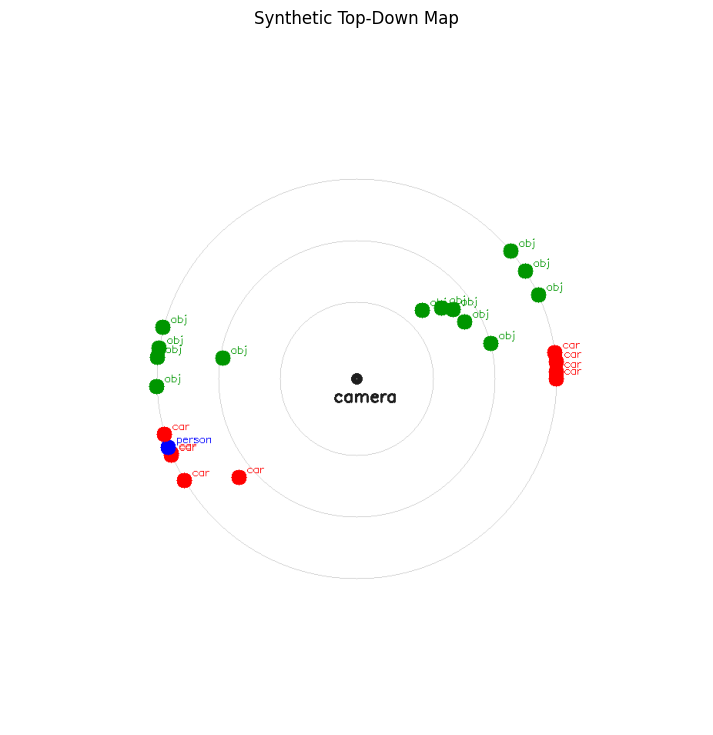

In [43]:
if surround_view is None:
    print("No surround-view image.")
else:
    display_image(surround_view, title="Synthetic Top-Down Map", figsize=(9, 9))
    save_image("outputs/surround_view.jpg", surround_view)